# **Session 8: Logistic Regression**

##### Business Example: Predicting Customer Churn

A mobile telecom company wants to **predict which customers are likely to churn**—i.e., discontinue their service. Using historical customer data and a binary indicator for churn (1 = churned, 0 = retained), the company applies **logistic regression** to estimate churn probabilities.

1. Load and Explore the Data

In [1]:
import pandas as pd
import numpy as np

# Import churn dataset
ChurnData = pd.read_csv("../Datasets/ChurnData.csv")
ChurnData.describe()

,Churn,RetExpense,Male
count,32.000000,32.000000,32.000000
mean,0.562500,20.090625,0.406250
std,0.504016,6.026948,0.498991
min,0.000000,10.400000,0.000000
25%,0.000000,15.425000,0.000000
50%,1.000000,19.200000,0.000000
75%,1.000000,22.800000,1.000000
max,1.000000,33.900000,1.000000


In [2]:
ChurnData['Churn'].value_counts()

Churn
1    18
0    14
Name: count, dtype: int64

In [3]:
ChurnData['Churn'].value_counts(normalize=True)

Churn
1    0.5625
0    0.4375
Name: proportion, dtype: float64

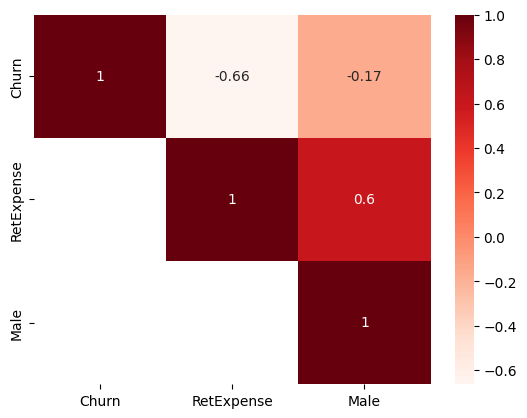

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

cor = ChurnData.corr()
mask = np.tril(np.ones_like(cor, dtype="bool"), k=-1)

# Plot correlation map
sns.heatmap(cor,
            mask=mask,
            annot=True,
            annot_kws={'size':10},
            cmap="Reds")
plt.show()

- 1.1. Barplot: Male vs average Churn rate

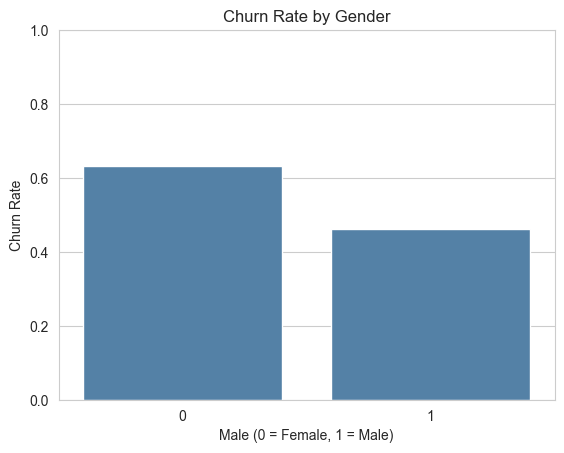

In [5]:
sns.set_style('whitegrid')
sns.barplot(data=ChurnData, x='Male', y='Churn', estimator=np.mean, color='steelblue', errorbar=None)
plt.title("Churn Rate by Gender")
plt.xlabel("Male (0 = Female, 1 = Male)")
plt.ylabel("Churn Rate")
plt.ylim(0,1)
plt.show()

- 1.2. Logistic regression curve: RetExpense vs Churn

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarn

<Figure size 900x500 with 0 Axes>

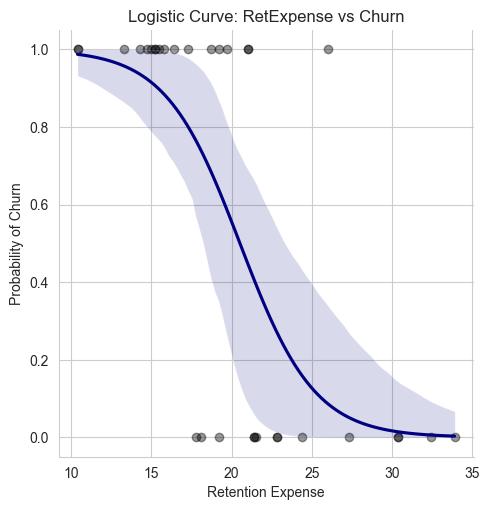

In [6]:
plt.figure(figsize=[9,5])
sns.set_style('whitegrid')
sns.lmplot(data=ChurnData, x='RetExpense', y='Churn', logistic=True, scatter_kws={'color': 'black', 'alpha': 0.4}, line_kws={'color': 'navy'})
plt.title("Logistic Curve: RetExpense vs Churn")
plt.xlabel("Retention Expense")
plt.ylabel("Probability of Churn")
plt.show()

2. Modeling Churn Probability

- 2.1. Model Estimation

In [7]:
ChurnData['Churn'] = ChurnData['Churn'].astype('category')

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimate the logistic regression model
X = sm.add_constant(ChurnData[['RetExpense','Male']])
Y = ChurnData['Churn']

glm1 = sm.Logit(Y,X).fit()
print(glm1.summary())

Optimization terminated successfully.
         Current function value: 0.322598
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                   32
Model:                          Logit   Df Residuals:                       29
Method:                           MLE   Df Model:                            2
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                  0.5293
Time:                        15:04:01   Log-Likelihood:                -10.323
converged:                       True   LL-Null:                       -21.930
Covariance Type:            nonrobust   LLR p-value:                 9.103e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.7051      4.625      2.747      0.006       3.640      21.771
RetExpense    -0.6809      0.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate Variance Inflation Factors (We will calculate the VIF without considering the constant applied in our model)
X1 = ChurnData[['RetExpense','Male']]

vif_values= pd.DataFrame()
vif_values['features'] = X1.columns
vif_values['VIF'] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]

vif_values

,features,VIF
0,RetExpense,2.226284
1,Male,2.226284


In R, the VIF is equal to ~1.78 for both variables. The differences between them are due to their calculation method, but small differences are observed.

- 2.2. Compute Odds Ratio

In [9]:
# Odds ratios with 95% confidence intervals
conf = glm1.conf_int()
conf['OR'] = glm1.params
conf.columns = ['2.5%', '97.5%', 'OR']

odds_ratio = np.exp(conf)
print(odds_ratio)

                 2.5%         97.5%             OR
const       38.077896  2.850036e+09  329428.889798
RetExpense   0.308640  8.300559e-01       0.506151
Male         0.880134  4.650889e+02      20.232169


In [10]:
coef = glm1.params
odds_ratios = np.exp(coef)
percent_change = (odds_ratios - 1)*100

results = pd.DataFrame({
    'Coefficiente': coef,
    'OddsRatio': odds_ratios,
    'PercentChange': percent_change
})
results

,Coefficiente,OddsRatio,PercentChange
const,12.705116,329428.889798,3.294279e+07
RetExpense,-0.680921,0.506151,-4.938491e+01
Male,3.007274,20.232169,1.923217e+03


- 2.3. Variable Importance: In the case of multiple predictor variable, we may  want to understand wich variables is the most influential in predicting the response(Y) variable    

In [11]:
stderr = glm1.bse
overall = abs(coef/stderr)

var_imp = pd.DataFrame({
    'Overall': overall.drop('const')
})
var_imp

,Overall
RetExpense,2.697983
Male,1.880138


3. Assessing Model Fit and Predictive Accuracy

We want to see how well our logistic model represents really

In [12]:
print('Log Likelihood: ', glm1.llf.round(4))
print('AIC: ', glm1.aic.round(4))
print('BIC: ', glm1.bic.round(4))
print('Pseudo-R2 (McFadden): ', (1- (glm1.llf / glm1.llnull).round(4)))

Log Likelihood:  -10.3231
AIC:  26.6463
BIC:  31.0435
Pseudo-R2 (McFadden):  0.5293


- 3.1. Classification with a Cutoff: We use a confusion matrix to evaluate the classification performance. Logistic regression produces probabilitis from 0 to 1 and we set a cut-off threshold, typically 0.5:

In [13]:
# 1. Calculate probability for each individual in the dataset
predicted = glm1.predict()  # Our predicted values take the form of an array

# 2. Add the predicted probability values to the dataset
ChurnData['predicted'] = predicted

# 3. Set classification threshold
cutoff_value = 0.5

# 4. Classify: 1 if predicted prob >= cutoff_value, else 0
df_classification = ChurnData[['Churn','predicted']]
df_classification['Yhat'] = np.where(df_classification['predicted'] >= cutoff_value, 1, 0)

df_classification.head(10)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11360\2309224354.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classification['Yhat'] = np.where(df_classification['predicted'] >= cutoff_value, 1, 0)


,Churn,predicted,Yhat
0,1,0.804248,1
1,1,0.804248,1
2,0,0.546714,1
3,0,0.133938,0
4,1,0.492976,0
5,0,0.593983,1
6,1,0.951105,1
7,0,0.019659,0
8,0,0.056260,0
9,0,0.408889,0


- 3.2. Confusion Matrix

In [14]:
# Confusio matrix manually
pd.crosstab(df_classification['Yhat'], df_classification['Churn'], margins=True)

Churn,0,1,All
Yhat,,,
0,10,3,13
1,4,15,19
All,14,18,32


In [15]:
from sklearn.metrics import confusion_matrix, classification_report

# Auto-generated confusion matrix
cm = confusion_matrix((df_classification['predicted'] >= cutoff_value).astype(int), df_classification['Churn'].astype(int))

print("Confussion Matrix:\n", cm)
print("Classification Report:\n", classification_report((df_classification['predicted'] >= cutoff_value).astype(int), df_classification['Churn'].astype(int)))

Confussion Matrix:
 [[10  3]
 [ 4 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74        13
           1       0.83      0.79      0.81        19

    accuracy                           0.78        32
   macro avg       0.77      0.78      0.78        32
weighted avg       0.78      0.78      0.78        32



In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, cohen_kappa_score, balanced_accuracy_score

# Model metrics
acc = accuracy_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= cutoff_value).astype(int))
pre = precision_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= cutoff_value).astype(int))
npv = precision_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= cutoff_value).astype(int), pos_label=0)
rec = recall_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= cutoff_value).astype(int))
spe = recall_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= cutoff_value).astype(int), pos_label=0)
kap = cohen_kappa_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= cutoff_value).astype(int))
bal = balanced_accuracy_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= cutoff_value).astype(int))

print("Accuracy: ", acc)
print("Precision: ", pre)
print("NPV: ", npv)
print("Sensitivity: ", rec)
print("Specificity: ", spe)
print("Kappa: ", kap)
print("Balanced Accuracy: ", bal)

Accuracy:  0.78125
Precision:  0.7894736842105263
NPV:  0.7692307692307693
Sensitivity:  0.8333333333333334
Specificity:  0.7142857142857143
Kappa:  0.552
Balanced Accuracy:  0.7738095238095238


- 3.3. Choosing the Cutoff

**Performance Metrics Comparison**

In [17]:
cutoff = [0.2, 0.5, 0.8]

Perf_Metrics = pd.DataFrame({
    'Metrics': ['Accuracy','Kappa','Sensitivity (Recall)','Specificity','Precision (PPV)','NPV','Balanced Accuracy']
})

for i in cutoff:

    acc1 = accuracy_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= i).astype(int))
    kap1 = cohen_kappa_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= i).astype(int))
    rec1 = recall_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= i).astype(int))
    spe1 = recall_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= i).astype(int), pos_label=0)
    pre1 = precision_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= i).astype(int))
    npv1 = precision_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= i).astype(int), pos_label=0)
    bal1 = balanced_accuracy_score(df_classification['Churn'].astype(int), (df_classification['predicted'] >= i).astype(int))    

    values = [acc1, kap1, rec1, spe1, pre1, npv1, bal1]
    Perf_Metrics[f'Cutoff = {i}'] = np.round(values,4)

Perf_Metrics

,Metrics,Cutoff = 0.2,Cutoff = 0.5,Cutoff = 0.8
0,Accuracy,0.8125,0.7812,0.8750
1,Kappa,0.6066,0.5520,0.7538
2,Sensitivity (Recall),0.9444,0.8333,0.7778
3,Specificity,0.6429,0.7143,1.0000
4,Precision (PPV),0.7727,0.7895,1.0000
5,NPV,0.9000,0.7692,0.7778
6,Balanced Accuracy,0.7937,0.7738,0.8889


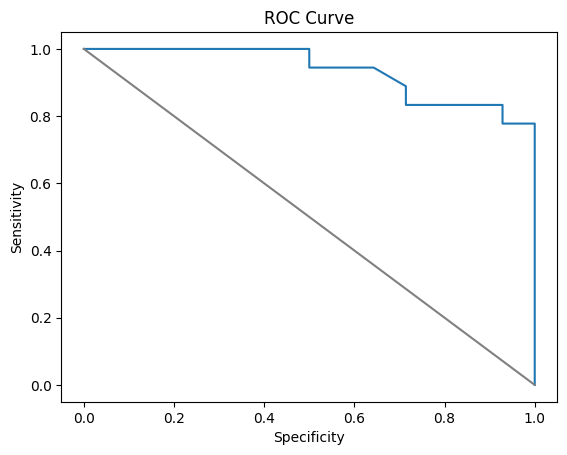

AUC:  0.9345238095238095


In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(ChurnData['Churn'], predicted)
roc_auc = auc(fpr, tpr)

sns.reset_orig()
plt.figure()
plt.plot(1-fpr, tpr)
plt.plot([1,0], [0,1], color="gray")
plt.title("ROC Curve")
plt.xlabel("Specificity")
plt.ylabel("Sensitivity")
plt.show()

print("AUC: ",roc_auc)

4. Predicting Churn Probability

In [19]:
# Parameter estimates from the logistic model
glm1.params

const         12.705116
RetExpense    -0.680921
Male           3.007274
dtype: float64

- Estimated model:

$$
\hat{P}(\text{Churn} = 1) = \frac{1}{1 + e^{-\left(12.7 - 0.68\cdot\text{RetExpense} + 3.01\cdot\text{Male}\right)}}
$$

In [20]:
new_df = pd.DataFrame({
    'RetExpense': [20,22],
    'Male': [1,1]
})

new_df = sm.add_constant(new_df, has_constant='add') # You have to force to add a constant because the model includes it because we are using statsmodel library
new_df = new_df[glm1.params.index] # Order the columns in the same way to the model

predicted1 = glm1.predict(new_df)
predicted1

0    0.890317
1    0.675274
dtype: float64

5. Cost-Benefit Analysis of Churn Retention Strategy

- Step 1: Set Business Assumptions

$$
\text{Total Profit} = 
\sum_i \Big[
    \underbrace{(TP_i \cdot (35 - R_i))}_{\text{gain from retained churners}} + 
    \underbrace{(FP_i \cdot (-R_i))}_{\text{cost of unnecessary retention}} + 
    \underbrace{(FN_i \cdot (-35))}_{\text{loss from lost customer}} + 
    \underbrace{(TN_i \cdot (0))}_{\text{no cost or gain}}
\Big]
$$

- Step 2: Predict Churn Probabilities

In [21]:
ChurnData['Prob'] = glm1.predict()

- Step 3: Choose a Cutoff Value

In [22]:
cutoff = 0.5
ChurnData['ChurnHat'] = np.where(ChurnData['Prob'] >= cutoff, 1, 0)

- Step 4: Label True/False Positive

In [23]:
ChurnData['TP'] = np.where((ChurnData['ChurnHat'] == 1) & (ChurnData['Churn'] == 1), 1, 0)
ChurnData['FP'] = np.where((ChurnData['ChurnHat'] == 1) & (ChurnData['Churn'] == 0), 1, 0)
ChurnData['FN'] = np.where((ChurnData['ChurnHat'] == 0) & (ChurnData['Churn'] == 1), 1, 0)

- Step 5: Compute the Payoff

In [29]:
Profits = 30
ChurnData['Payoff'] = ((ChurnData['TP']*(Profits - ChurnData['RetExpense'])) + 
          (ChurnData['FP']*(-ChurnData['RetExpense'])) + 
          (ChurnData['FN']*(-Profits)))

Payoff = ChurnData['Payoff'].sum()
print(round(Payoff,1))

44.7


**Benchmark Comparison**

In [28]:
Profits = 35

total_retention_cost = ChurnData['RetExpense'].sum()
total_retention_profit = 18*Profits

benchmark_payoff = total_retention_profit - total_retention_cost
print(round(benchmark_payoff,1))

-12.9


In [42]:
# Alternatively:
Benchmark = (35*(sum(ChurnData[ChurnData['Churn'] == 1]['Churn']))) - (ChurnData['RetExpense'].sum())
print("Benchmark: ", round(Benchmark,1))

Benchmark:  -12.9


- Step 6: Optimize Cutoff

In [53]:
# Define cutoff grid
cutoff_grid = np.arange(0.1, 1, 0.05)
profit_per_retained = 35

# Initialize results table
PayoffMatrix = pd.DataFrame({
    'Cutoff': cutoff_grid,
    'Payoff': np.nan
})

# Loop over cutoffs and calculate payoff
for idx, cutoff_i in enumerate(cutoff_grid):

    ChurnData['ChurnHat'] = np.where(ChurnData['Prob'] >= cutoff_i, 1, 0)
    ChurnData['TP'] = np.where((ChurnData['ChurnHat'] == 1) & (ChurnData['Churn'] == 1), 1, 0)
    ChurnData['FP'] = np.where((ChurnData['ChurnHat'] == 1) & (ChurnData['Churn'] == 0), 1, 0)
    ChurnData['FN'] = np.where((ChurnData['ChurnHat'] == 0) & (ChurnData['Churn'] == 1), 1, 0)

    ChurnData['IndividualPayoff'] = (ChurnData['TP']*(profit_per_retained - ChurnData['RetExpense']) + ChurnData['FP']*(-ChurnData['RetExpense']) + ChurnData['FN']*(-profit_per_retained))
    total_payoff = ChurnData['IndividualPayoff'].sum()

    PayoffMatrix.loc[idx, 'Payoff'] = total_payoff

PayoffMatrix

,Cutoff,Payoff
0,0.10,188.7
1,0.15,187.6
2,0.20,187.6
3,0.25,187.6
4,0.30,187.6
5,0.35,187.6
6,0.40,187.6
7,0.45,156.0
8,0.50,104.7
9,0.55,127.5


In [63]:
# Identify the optimal cutoff
OptimalCutoff = PayoffMatrix.loc[PayoffMatrix['Payoff'].idxmax()]['Cutoff']
OptimalCutoff

np.float64(0.1)

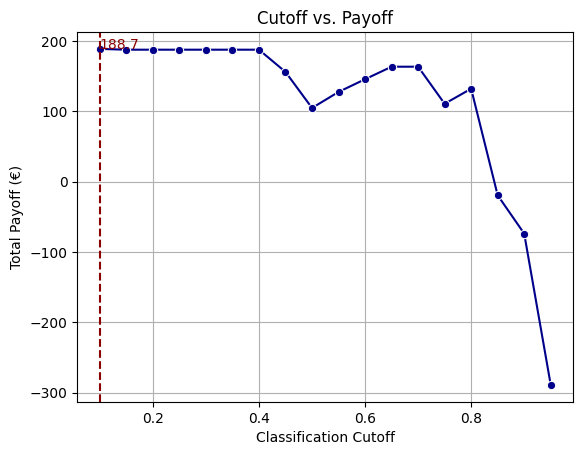

In [78]:
sns.reset_orig()
sns.lineplot(data=PayoffMatrix, x='Cutoff', y='Payoff', marker="o", color="darkblue")
plt.axvline(x=OptimalCutoff, color="darkred", linestyle='--')
plt.text(OptimalCutoff, PayoffMatrix.loc[PayoffMatrix['Payoff'].idxmax()]['Payoff'], s=PayoffMatrix.loc[PayoffMatrix['Payoff'].idxmax()]['Payoff'], color="darkred")
plt.title("Cutoff vs. Payoff")
plt.xlabel("Classification Cutoff")
plt.ylabel("Total Payoff (€)")
plt.grid(True)
plt.show()

**Optinal Visual: Targeting Map**

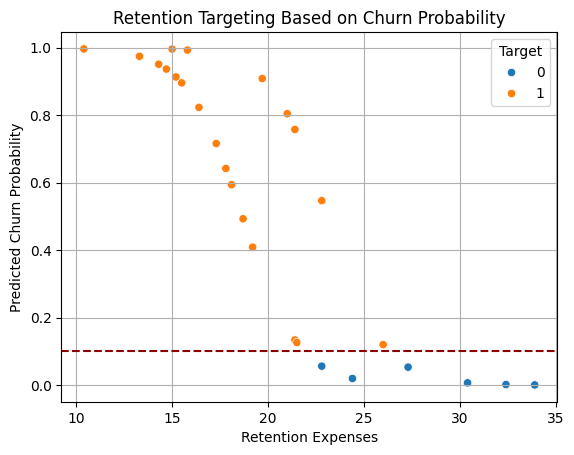

In [85]:
ChurnData['Target'] = np.where(ChurnData['Prob'] >= OptimalCutoff, 1, 0)

sns.scatterplot(data=ChurnData, x='RetExpense', y='Prob', hue='Target')
plt.axhline(y=OptimalCutoff, color="darkred", linestyle='--')
plt.grid(True)
plt.title("Retention Targeting Based on Churn Probability")
plt.xlabel("Retention Expenses")
plt.ylabel("Predicted Churn Probability")
plt.show()